<a href="https://colab.research.google.com/github/mahidhargubbala-pixel/student-performance-analysis/blob/main/fraud_detection_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Card Fraud Detection — Real-World Data Project

## Business Problem
Credit card fraud causes billions in losses annually.
The challenge: fraud is extremely rare (~0.17% of all
transactions), making it a hard target for standard
classification approaches.

## Dataset
284,807 real, anonymized European credit card
transactions (Kaggle: mlg-ulb/creditcardfraud), with
492 confirmed fraud cases.

## Approach
1. Explored the severe class imbalance and its impact
   on naive accuracy-based evaluation
2. Scaled Amount and Time features
3. Used a stratified train/test split to preserve fraud
   ratio in both sets
4. Trained Logistic Regression and Random Forest, both
   with class_weight="balanced" to address imbalance
5. Evaluated using Precision, Recall, F1-score, and
   Confusion Matrices — not accuracy, which is misleading
   here
6. Compared the precision-recall trade-off between models

## Key Findings
- A model that looks 99.9% "accurate" can still miss
  most fraud cases — accuracy is the wrong metric for
  imbalanced problems
- Logistic Regression achieved high Recall (91.8%) but
  very low Precision (6%) — catches most fraud but with
  excessive false alarms
- Random Forest achieved a much better balance: 96.1%
  Precision and 75.5% Recall (F1 = 0.85)
- A handful of anonymized features (e.g. V14, V10, V12)
  account for most of the model's predictive power

## Business Recommendation
Deploy the Random Forest model for production fraud
flagging — it minimizes customer friction (fewer false
declines) while still catching the majority of fraud.
For higher-risk use cases, the detection threshold can
be tuned to favor Recall over Precision.

## Tools Used
Python, Pandas, Scikit-learn, Matplotlib, Seaborn

## Dataset Source
Kaggle: ULB Machine Learning Group — Credit Card Fraud
Detection Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, confusion_matrix, classification_report,
                              roc_curve, auc, precision_recall_curve)

In [2]:
!pip install kaggle -q
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

!kaggle datasets download -d mlg-ulb/creditcardfraud
!unzip -o creditcardfraud.zip

cp: cannot stat 'kaggle.json': No such file or directory
chmod: cannot access '/root/.kaggle/kaggle.json': No such file or directory
Dataset URL: https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud
License(s): DbCL-1.0
100% 66.0M/66.0M [00:00<00:00, 145MB/s]

Archive:  creditcardfraud.zip
  inflating: creditcard.csv          


In [3]:
df = pd.read_csv("creditcard.csv")
print("Shape:", df.shape)
df.head()

Shape: (284807, 31)


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [4]:
print(df["Class"].value_counts())
print("\nPercentage breakdown:")
print(df["Class"].value_counts(normalize=True) * 100)

Class
0    284315
1       492
Name: count, dtype: int64

Percentage breakdown:
Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64


/tmp/ipykernel_1041/3023190283.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x="Class", palette=["#4C72B0", "#C44E52"])


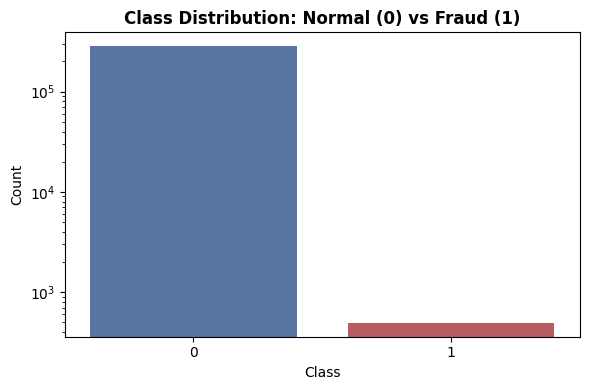

In [5]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Class", palette=["#4C72B0", "#C44E52"])
plt.title("Class Distribution: Normal (0) vs Fraud (1)", fontweight="bold")
plt.xlabel("Class")
plt.ylabel("Count")
plt.yscale("log")  # log scale because the gap is so huge
plt.tight_layout()
plt.show()

In [6]:
print("Amount stats - Normal transactions:")
print(df[df["Class"]==0]["Amount"].describe())

print("\nAmount stats - Fraud transactions:")
print(df[df["Class"]==1]["Amount"].describe())

Amount stats - Normal transactions:
count    284315.000000
mean         88.291022
std         250.105092
min           0.000000
25%           5.650000
50%          22.000000
75%          77.050000
max       25691.160000
Name: Amount, dtype: float64

Amount stats - Fraud transactions:
count     492.000000
mean      122.211321
std       256.683288
min         0.000000
25%         1.000000
50%         9.250000
75%       105.890000
max      2125.870000
Name: Amount, dtype: float64


/tmp/ipykernel_1041/2731602284.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#4C72B0","#C44E52"])
/tmp/ipykernel_1041/2731602284.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], palette=["#4C72B0","#C44E52"], showfliers=False)


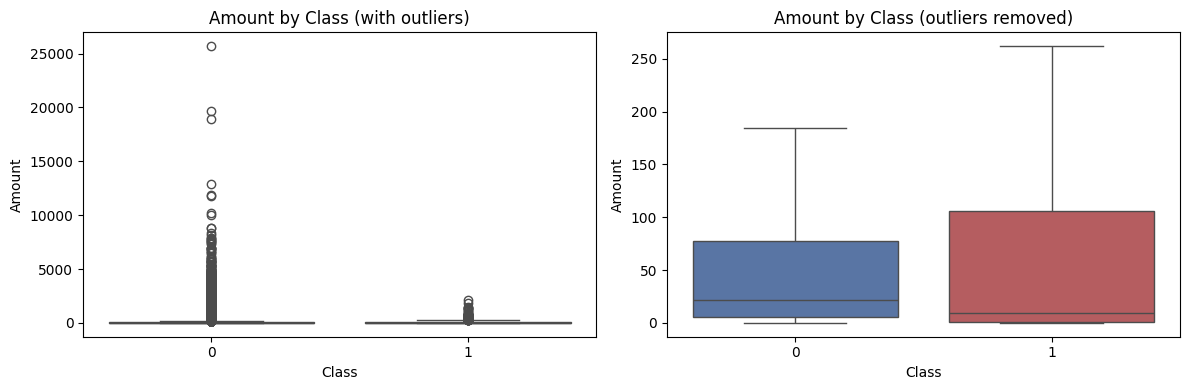

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[0], palette=["#4C72B0","#C44E52"])
axes[0].set_title("Amount by Class (with outliers)")

sns.boxplot(data=df, x="Class", y="Amount", ax=axes[1], palette=["#4C72B0","#C44E52"], showfliers=False)
axes[1].set_title("Amount by Class (outliers removed)")

plt.tight_layout()
plt.show()

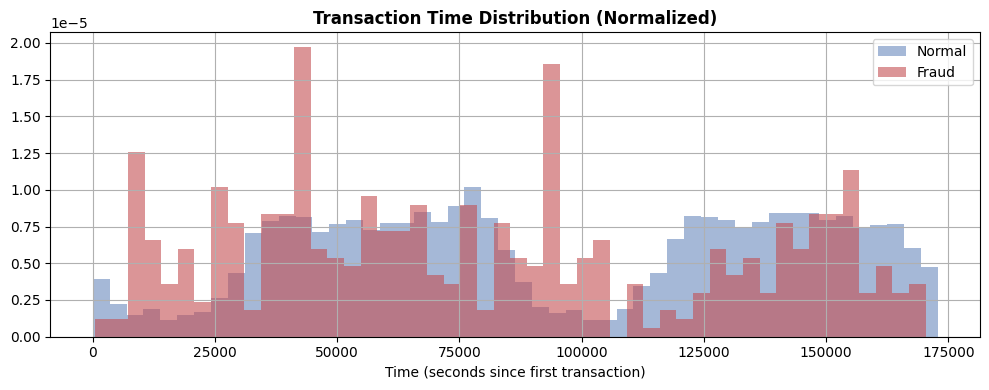

In [8]:
plt.figure(figsize=(10, 4))
df[df["Class"]==0]["Time"].hist(bins=50, alpha=0.5, label="Normal", color="#4C72B0", density=True)
df[df["Class"]==1]["Time"].hist(bins=50, alpha=0.6, label="Fraud", color="#C44E52", density=True)
plt.legend()
plt.title("Transaction Time Distribution (Normalized)", fontweight="bold")
plt.xlabel("Time (seconds since first transaction)")
plt.tight_layout()
plt.show()

In [9]:
scaler = StandardScaler()
df["Amount_scaled"] = scaler.fit_transform(df[["Amount"]])
df["Time_scaled"] = scaler.fit_transform(df[["Time"]])

df = df.drop(["Amount", "Time"], axis=1)
print(df.head())

         V1        V2        V3        V4        V5        V6        V7  \
0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9       V10  ...       V22       V23       V24       V25  \
0  0.098698  0.363787  0.090794  ...  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425 -0.166974  ... -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  0.207643  ...  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024 -0.054952  ...  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  0.753074  ...  0.798278 -0.137458  0.141267 -0.206010   

        V26       V27       V28  Class  Amount_scaled  Time_scaled  

In [10]:
X = df.drop("Class", axis=1)
y = df["Class"]

print("Features shape:", X.shape)
print("Target distribution:\n", y.value_counts())

Features shape: (284807, 30)
Target distribution:
 Class
0    284315
1       492
Name: count, dtype: int64


In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train fraud cases:", y_train.sum())
print("Test fraud cases:", y_test.sum())

Train fraud cases: 394
Test fraud cases: 98


In [12]:
log_basic = LogisticRegression(max_iter=1000)
log_basic.fit(X_train, y_train)
pred_basic = log_basic.predict(X_test)

print("=== WITHOUT handling imbalance ===")
print(f"Accuracy : {accuracy_score(y_test, pred_basic):.4f}")
print(f"Precision: {precision_score(y_test, pred_basic):.4f}")
print(f"Recall   : {recall_score(y_test, pred_basic):.4f}")
print(f"F1 Score : {f1_score(y_test, pred_basic):.4f}")

=== WITHOUT handling imbalance ===
Accuracy : 0.9992
Precision: 0.8289
Recall   : 0.6429
F1 Score : 0.7241


In [13]:
log_balanced = LogisticRegression(max_iter=1000, class_weight="balanced")
log_balanced.fit(X_train, y_train)
pred_balanced = log_balanced.predict(X_test)

print("=== WITH class_weight='balanced' ===")
print(f"Accuracy : {accuracy_score(y_test, pred_balanced):.4f}")
print(f"Precision: {precision_score(y_test, pred_balanced):.4f}")
print(f"Recall   : {recall_score(y_test, pred_balanced):.4f}")
print(f"F1 Score : {f1_score(y_test, pred_balanced):.4f}")

=== WITH class_weight='balanced' ===
Accuracy : 0.9755
Precision: 0.0609
Recall   : 0.9184
F1 Score : 0.1141


In [14]:
forest = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42, n_jobs=-1)
forest.fit(X_train, y_train)
pred_forest = forest.predict(X_test)

print("=== Random Forest (balanced) ===")
print(f"Accuracy : {accuracy_score(y_test, pred_forest):.4f}")
print(f"Precision: {precision_score(y_test, pred_forest):.4f}")
print(f"Recall   : {recall_score(y_test, pred_forest):.4f}")
print(f"F1 Score : {f1_score(y_test, pred_forest):.4f}")

=== Random Forest (balanced) ===
Accuracy : 0.9995
Precision: 0.9610
Recall   : 0.7551
F1 Score : 0.8457


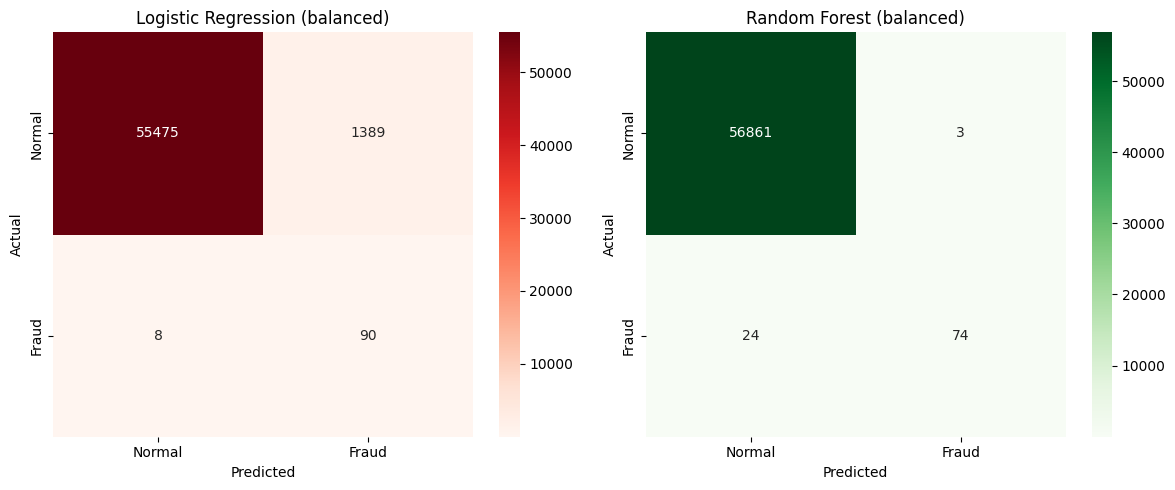

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

cm1 = confusion_matrix(y_test, pred_balanced)
sns.heatmap(cm1, annot=True, fmt="d", cmap="Reds", ax=axes[0],
            xticklabels=["Normal","Fraud"], yticklabels=["Normal","Fraud"])
axes[0].set_title("Logistic Regression (balanced)")
axes[0].set_xlabel("Predicted"); axes[0].set_ylabel("Actual")

cm2 = confusion_matrix(y_test, pred_forest)
sns.heatmap(cm2, annot=True, fmt="d", cmap="Greens", ax=axes[1],
            xticklabels=["Normal","Fraud"], yticklabels=["Normal","Fraud"])
axes[1].set_title("Random Forest (balanced)")
axes[1].set_xlabel("Predicted"); axes[1].set_ylabel("Actual")

plt.tight_layout()
plt.show()

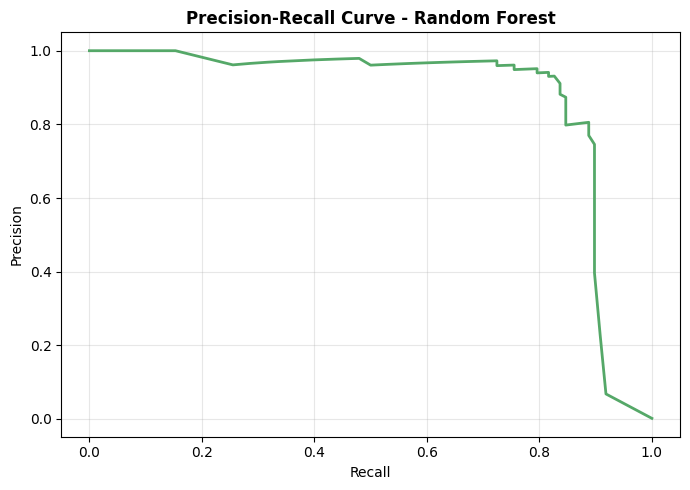

In [16]:
forest_proba = forest.predict_proba(X_test)[:, 1]
precision, recall, thresholds = precision_recall_curve(y_test, forest_proba)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, color="#55A868", linewidth=2)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Random Forest", fontweight="bold")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

   Feature  Importance
13     V14    0.209889
9      V10    0.117423
3       V4    0.114414
16     V17    0.087311
11     V12    0.072560
10     V11    0.071794
2       V3    0.068853
15     V16    0.037365
6       V7    0.031200
1       V2    0.025360


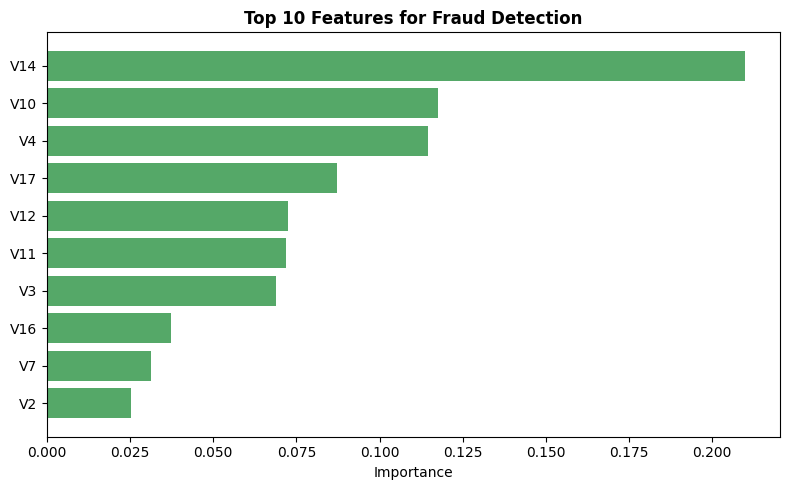

In [18]:
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": forest.feature_importances_
}).sort_values("Importance", ascending=False).head(10)

print(importance)

plt.figure(figsize=(8, 5))
plt.barh(importance["Feature"], importance["Importance"], color="#55A868")
plt.xlabel("Importance")
plt.title("Top 10 Features for Fraud Detection", fontweight="bold")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [19]:
print("="*55)
print("   CREDIT CARD FRAUD DETECTION — SUMMARY")
print("="*55)
print(f"Dataset Size        : {df.shape[0]:,} transactions")
print(f"Fraud Cases         : {y.sum()} ({y.mean()*100:.3f}%)")
print(f"\nBest Model          : Random Forest (class_weight='balanced')")
print(f"Accuracy            : {accuracy_score(y_test, pred_forest):.4f}")
print(f"Precision           : {precision_score(y_test, pred_forest):.4f}")
print(f"Recall              : {recall_score(y_test, pred_forest):.4f}")
print(f"F1 Score            : {f1_score(y_test, pred_forest):.4f}")
print(f"\nTop Predictor       : {importance.iloc[0]['Feature']}")
print("="*55)

   CREDIT CARD FRAUD DETECTION — SUMMARY
Dataset Size        : 284,807 transactions
Fraud Cases         : 492 (0.173%)

Best Model          : Random Forest (class_weight='balanced')
Accuracy            : 0.9995
Precision           : 0.9610
Recall              : 0.7551
F1 Score            : 0.8457

Top Predictor       : V14
